# Image Recognition Project — Model 3: Fine-Tuned EfficientNet-B0
**Classes:** Fumo · Chocopuni 

Model 3 builds directly on Model 2 by unfreezing more layers of EfficientNet-B0
and allowing them to adapt to our specific dataset.

More trainable parameters on a small dataset = higher overfitting risk.
We manage this with lower learning rates on pretrained layers, strong augmentation,
and K-Fold cross-validation.

## 1. Imports

In [1]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, ConcatDataset, Subset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedKFold
import itertools
import torch.nn as nn

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")

PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU: NVIDIA GeForce RTX 5080
Compute capability: (12, 0)


## 2. Configuration

Fine-tuning requires more conservative learning rates than feature extraction.
Since pretrained weights are already good, we nudge them gently rather than
overwriting them aggressively.

| Parameter | Model 2 | Model 3 | Reason for change |
|-----------|---------|---------|-------------------|
| `LR_HEAD` | 1e-3 | 1e-3 | Same — classifier head is still randomly initialized |
| `LR_UNFREEZE` | 1e-4 | 1e-5 | Lower — more layers unfrozen, need more caution |
| `LR_FROZEN` | — | 0 | Frozen layers get no gradient updates |
| `EPOCHS` | 30 | 40 | More epochs to let deeper adaptation converge |
| `EARLY_STOP_PATIENCE` | 10 | 10 | Same |

In [ ]:
torch.set_float32_matmul_precision('high')

IMG_SIZE            = 299
BATCH_SIZE          = 32
EPOCHS              = 40
LR_HEAD             = 1e-3   # Classifier head — randomly initialized, can learn fast
LR_UNFREEZE         = 1e-6  
WEIGHT_DECAY        = 1e-4
NUM_WORKERS         = 10
EARLY_STOP_PATIENCE = 10
N_FOLDS             = 5
SEED                = 42

model_dir = "models/fine_tuning"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Data Transforms & Loading

Same transforms as Model 2 for a fair comparison.
Augmentation is identical so any performance difference comes from the model
architecture, not data preprocessing.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = datasets.ImageFolder("./data/test", transform=val_test_transform)

CLASS_NAMES = datasets.ImageFolder("./data/train").classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Test: {len(test_dataset)}")

Found 2 classes: ['chocopuni', 'fumo']
Test: 48


## 4. Cross-Validation Data Pool

Same K-Fold setup as Model 2 — train and validation folders are merged into
one pool and split stratified by class label, ensuring each fold sees a
balanced representation of all classes.

In [4]:
train_folder = datasets.ImageFolder("./data/train")
val_folder   = datasets.ImageFolder("./data/validation")

all_targets = (
    [s[1] for s in train_folder.samples] +
    [s[1] for s in val_folder.samples]
)

pool_with_aug = ConcatDataset([
    datasets.ImageFolder("./data/train",      transform=train_transform),
    datasets.ImageFolder("./data/validation", transform=train_transform),
])
pool_no_aug = ConcatDataset([
    datasets.ImageFolder("./data/train",      transform=val_test_transform),
    datasets.ImageFolder("./data/validation", transform=val_test_transform),
])

print(f"Total pool size: {len(pool_with_aug)} images across {NUM_CLASSES} classes")
print(f"Class distribution: { {cls: all_targets.count(i) for i, cls in enumerate(CLASS_NAMES)} }")

Total pool size: 281 images across 2 classes
Class distribution: {'chocopuni': 139, 'fumo': 142}


## 5. Model Architecture — Fine-Tuned EfficientNet-B0

EfficientNet-B0's features block has 9 layers (indices 0–8)

Low-level features (edges, textures, basic shapes) learned from ImageNet are
universally useful and unlikely to need adjustment for plushie recognition.
Freezing them also prevents catastrophic forgetting and reduces the risk of
overfitting on our small dataset.

Each section of the network has a different role:
- Frozen layers (0): Already optimal, don't touch
- Upper conv blocks (1e-5): Pretrained but benefit from gentle task-specific tuning
- Classifier head (1e-3): Randomly initialized, needs to learn fast

In [ ]:
UNFREEZE_FROM = 7  # Unfreeze features[6], features[7], features[8]

def build_finetuned_model(num_classes):
    effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Step 1: Freeze everything
    for param in effnet.parameters():
        param.requires_grad = False

    # Step 2: Unfreeze the last 3 conv blocks (features[6], [7], [8])
    for i in range(UNFREEZE_FROM, len(effnet.features)):
        for param in effnet.features[i].parameters():
            param.requires_grad = True

    # Step 3: Replace classifier head
    in_features = effnet.classifier[1].in_features  # 1280
    effnet.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes),
    )

    return effnet.to(DEVICE)


model = build_finetuned_model(NUM_CLASSES)
model = torch.compile(model)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters : {total_params:,}")
print(f"Trainable        : {trainable_params:,}")
print(f"Frozen           : {total_params - trainable_params:,}")
print(f"Trainable share  : {trainable_params/total_params*100:.1f} %")
print()
print("Layer status:")
for i, block in enumerate(model.features):
    status = "UNFROZEN" if i >= UNFREEZE_FROM else "frozen"
    trainable = sum(p.numel() for p in block.parameters() if p.requires_grad)
    print(f"  features[{i}]: {status}  ({trainable:,} trainable params)")

Total parameters : 4,010,110
Trainable        : 1,131,954
Frozen           : 2,878,156
Trainable share  : 28.2 %

Layer status:
  features[0]: frozen  (0 trainable params)
  features[1]: frozen  (0 trainable params)
  features[2]: frozen  (0 trainable params)
  features[3]: frozen  (0 trainable params)
  features[4]: frozen  (0 trainable params)
  features[5]: frozen  (0 trainable params)
  features[6]: frozen  (0 trainable params)
  features[7]: UNFROZEN  (717,232 trainable params)
  features[8]: UNFROZEN  (412,160 trainable params)


## 6. Training Loop

Identical structure to Model 2 for a fair comparison.
Mixed precision (`torch.autocast`) is used for faster GPU computation.

In [6]:
criterion = nn.CrossEntropyLoss()
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataloader. No gradients computed."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total

## 7. Stratified K-Fold Cross-Validation

### Key difference from Model 2: three parameter groups in the optimizer

Model 2 used two parameter groups (frozen backbone + classifier).
Model 3 uses two active groups with different learning rates:

```python
optimizer = AdamW([
    {"params": features[6,7,8],  "lr": 1e-5},  # gentle fine-tuning
    {"params": classifier,        "lr": 1e-3},  # fast learning
])
```

This ensures pretrained weights are only nudged slightly while the new
classifier head learns quickly from scratch.

In [7]:
for fold, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(all_targets)), all_targets), 1):

    print(f"\n{'='*50}")
    print(f"  Fold {fold}/{N_FOLDS}  (train={len(train_idx)}, val={len(val_idx)})")
    print(f"{'='*50}")

    fold_train_loader = DataLoader(
        Subset(pool_with_aug, train_idx),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        prefetch_factor=4,
    )
    fold_val_loader = DataLoader(
        Subset(pool_no_aug, val_idx),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        prefetch_factor=4,
    )

    model = build_finetuned_model(NUM_CLASSES)

    # Collect unfrozen conv block parameters
    unfrozen_conv_params = []
    for i in range(UNFREEZE_FROM, len(model.features)):
        unfrozen_conv_params += list(model.features[i].parameters())

    # Two learning rates: low for pretrained layers, high for new head
    optimizer = torch.optim.AdamW([
        {"params": unfrozen_conv_params,          "lr": LR_UNFREEZE},
        {"params": model.classifier.parameters(), "lr": LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)

    # Halve LR if val_loss doesn't improve for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_loss    = float("inf")
    best_val_acc     = 0.0
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model, fold_train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(
            model, fold_val_loader, criterion, DEVICE)

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = val_acc
            torch.save(model.state_dict(), f"{model_dir}/best_fold{fold}.pth")
            saved = " ← saved"
            patience_counter = 0
        else:
            saved = ""
            patience_counter += 1

        print(f"  Epoch {epoch:2d}/{EPOCHS} | "
              f"train: loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val: loss={val_loss:.4f} acc={val_acc:.3f}{saved}")

        if patience_counter >= EARLY_STOP_PATIENCE:
            print("  Early stopping.")
            break

    fold_results.append((fold, best_val_acc, best_val_loss))
    print(f"  Fold {fold} best val acc: {best_val_acc:.3f}")

# ── Summary ───────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"K-Fold Results ({N_FOLDS} folds):")
for fold, acc, loss in fold_results:
    print(f"  Fold {fold}: {acc:.3f} ({acc*100:.1f}%)")

accs = [r[1] for r in fold_results]
print(f"  Mean      : {np.mean(accs):.3f} ({np.mean(accs)*100:.1f}%)")
print(f"  Std dev   : {np.std(accs):.3f}")

best_fold = max(fold_results, key=lambda x: x[1])
print(f"\nBest fold: Fold {best_fold[0]} ({best_fold[1]*100:.1f}%)")
print(f"Loading best model: best_fold{best_fold[0]}.pth")

model = build_finetuned_model(NUM_CLASSES)
model.load_state_dict(
    torch.load(
        f"{model_dir}/best_fold{best_fold[0]}.pth",
        map_location=DEVICE,
        weights_only=True,
    )
)


  Fold 1/5  (train=224, val=57)
  Epoch  1/40 | train: loss=0.6831 acc=0.549 | val: loss=0.6429 acc=0.632 ← saved
  Epoch  2/40 | train: loss=0.6139 acc=0.692 | val: loss=0.5891 acc=0.807 ← saved
  Epoch  3/40 | train: loss=0.5733 acc=0.772 | val: loss=0.5457 acc=0.842 ← saved
  Epoch  4/40 | train: loss=0.5016 acc=0.862 | val: loss=0.5002 acc=0.842 ← saved
  Epoch  5/40 | train: loss=0.4744 acc=0.853 | val: loss=0.4718 acc=0.842 ← saved
  Epoch  6/40 | train: loss=0.4296 acc=0.875 | val: loss=0.4475 acc=0.877 ← saved
  Epoch  7/40 | train: loss=0.4175 acc=0.884 | val: loss=0.4201 acc=0.912 ← saved
  Epoch  8/40 | train: loss=0.4318 acc=0.817 | val: loss=0.4025 acc=0.930 ← saved
  Epoch  9/40 | train: loss=0.3595 acc=0.893 | val: loss=0.3770 acc=0.930 ← saved
  Epoch 10/40 | train: loss=0.3754 acc=0.871 | val: loss=0.3651 acc=0.930 ← saved
  Epoch 11/40 | train: loss=0.3535 acc=0.888 | val: loss=0.3515 acc=0.930 ← saved
  Epoch 12/40 | train: loss=0.3464 acc=0.906 | val: loss=0.3384 a

<All keys matched successfully>

## 8. Learning Curves

### What to expect vs Model 2:
- Training should converge **more slowly** — more parameters to optimize
- Validation accuracy may be **higher** if fine-tuning captures plushie-specific features better
- Watch for a **wider train/val gap** — more trainable parameters = higher overfitting risk
- If val loss spikes while train loss drops, fine-tuning is too aggressive (consider reducing `LR_UNFREEZE`)

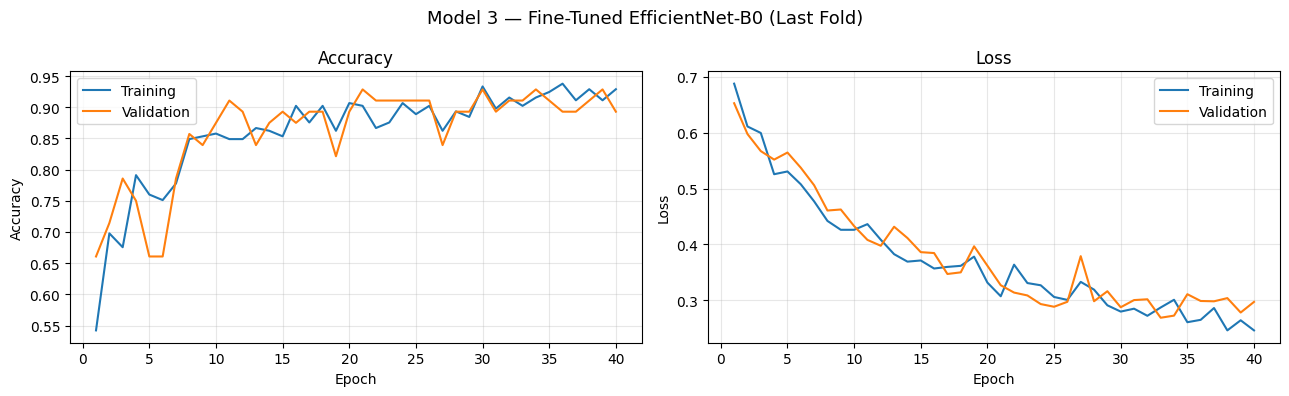

In [8]:
def plot_history(history, title):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13)

    ax1.plot(epochs, history["train_acc"], label="Training")
    ax1.plot(epochs, history["val_acc"],   label="Validation")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_loss"], label="Training")
    ax2.plot(epochs, history["val_loss"],   label="Validation")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, "Model 3 — Fine-Tuned EfficientNet-B0 (Last Fold)")

## 9. Test Evaluation — Best Saved Model

> ⚠️ Only evaluate on the test set once all tuning decisions are finalized.

In [9]:
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False
)

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"=== Test Results — Model 3 ===")
print(f"Accuracy : {test_acc:.3f}  ({test_acc * 100:.1f} %)")
print(f"Loss     : {test_loss:.3f}")

=== Test Results — Model 3 ===
Accuracy : 0.917  (91.7 %)
Loss     : 0.392


## 10. Prediction Grid

Balanced sample from the test set — equal images per class, shuffled randomly.
- **Green** = correct prediction
- **Red** = wrong prediction

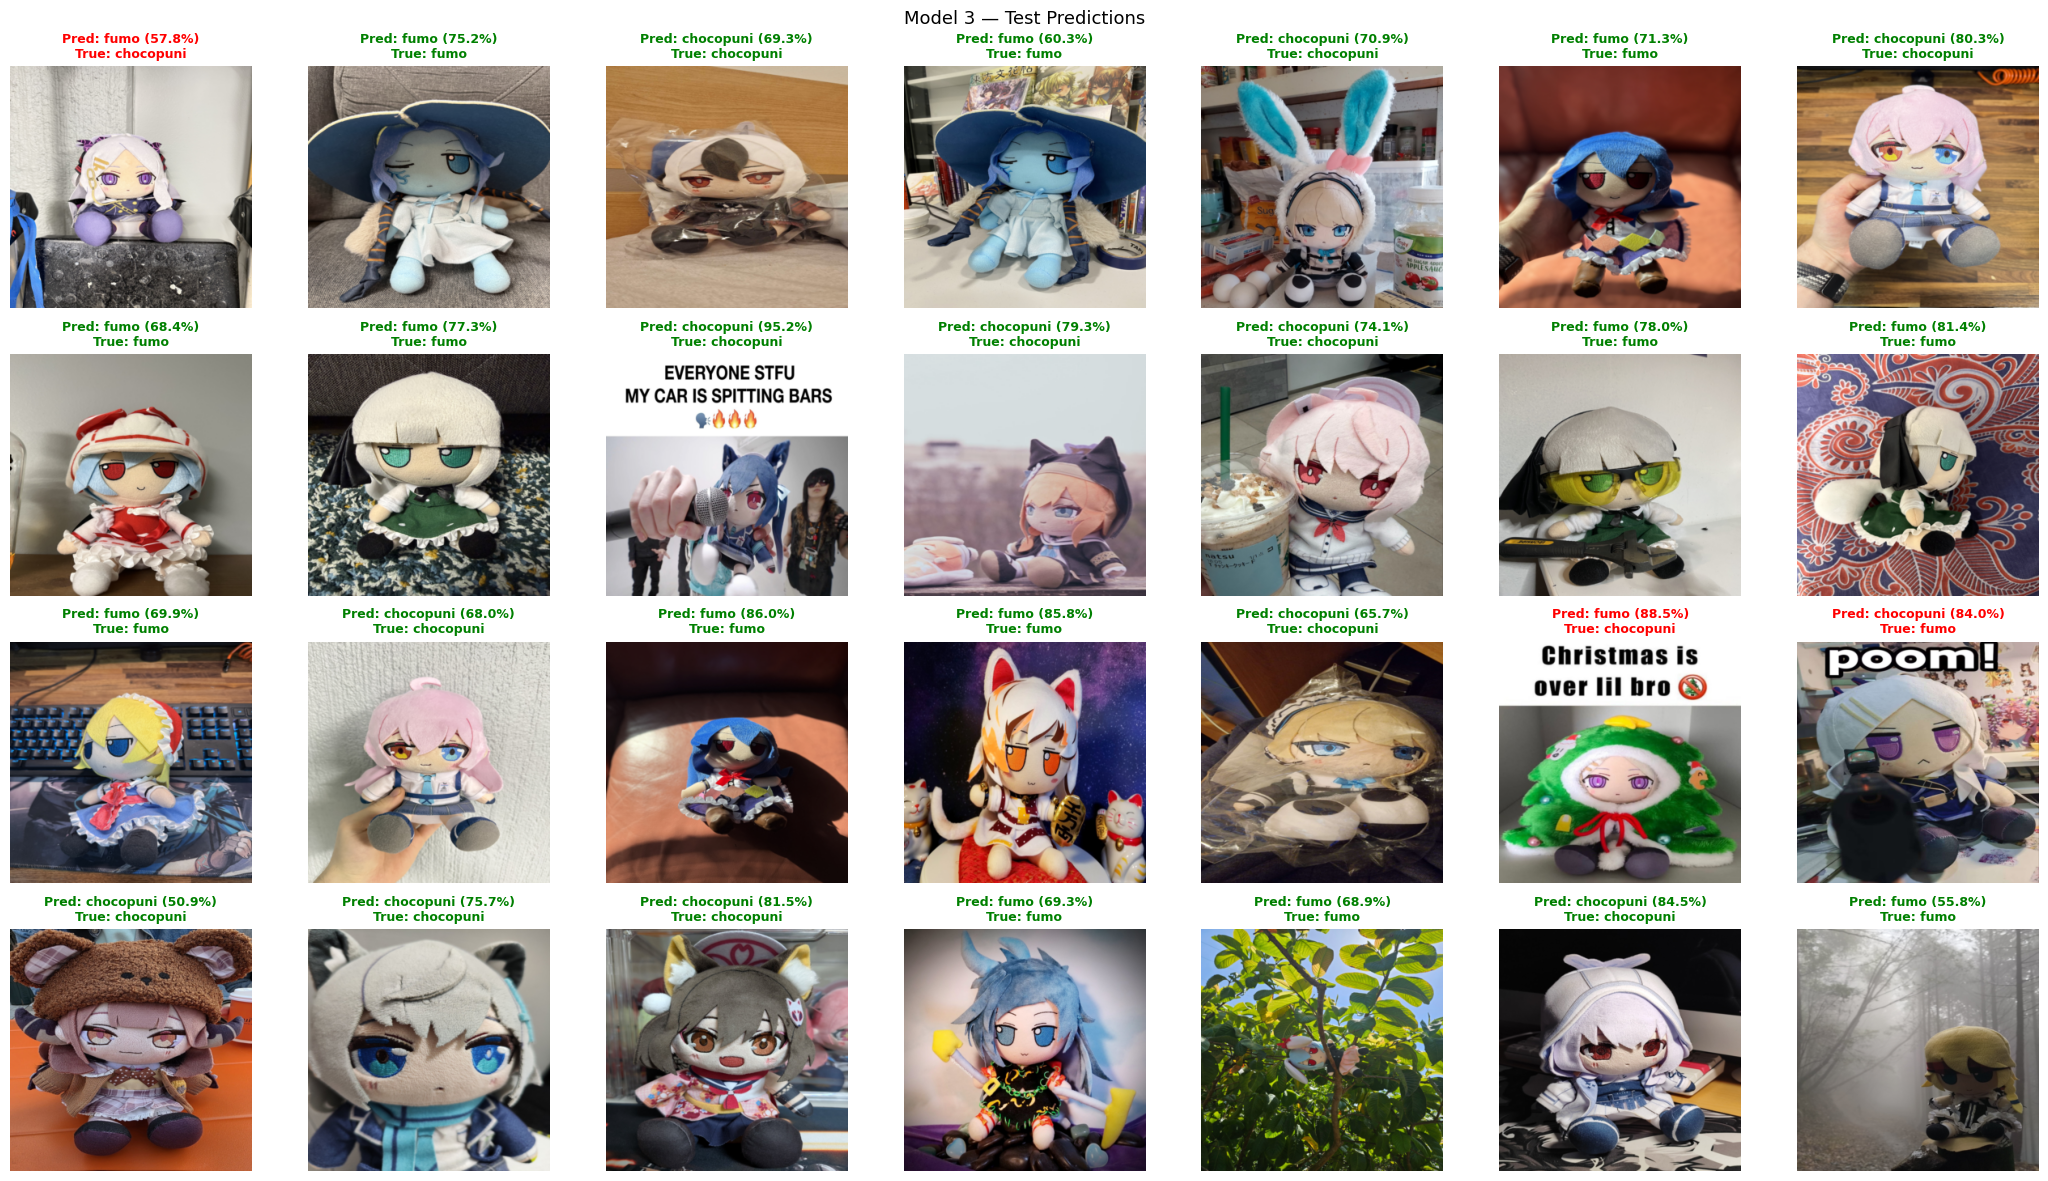

In [10]:
import math
import random

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)

n_per_class = 14
buckets       = {i: [] for i in range(NUM_CLASSES)}
bucket_labels = {i: [] for i in range(NUM_CLASSES)}

for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        cls = lbl.item()
        if len(buckets[cls]) < n_per_class:
            buckets[cls].append(img)
            bucket_labels[cls].append(lbl)
    if all(len(v) >= n_per_class for v in buckets.values()):
        break

selected = []
for cls in range(NUM_CLASSES):
    idx = random.sample(range(len(buckets[cls])), min(n_per_class, len(buckets[cls])))
    selected += [(buckets[cls][i], bucket_labels[cls][i]) for i in idx]

random.shuffle(selected)
images, labels = zip(*selected)
images = torch.stack(images)
n = len(images)

with torch.no_grad():
    outputs = model(images.to(DEVICE))
    probs   = torch.softmax(outputs, dim=1).cpu().numpy()

cols = 7
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 3, rows * 3))

for i in range(n):
    pred_idx   = np.argmax(probs[i])
    confidence = probs[i][pred_idx]
    true_idx   = labels[i].item()
    img_plot   = denormalize(images[i]).permute(1, 2, 0).numpy()

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_plot)
    color = "green" if pred_idx == true_idx else "red"
    plt.title(
        f"Pred: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)\n"
        f"True: {CLASS_NAMES[true_idx]}",
        color=color, fontsize=9, fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Model 3 — Test Predictions", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Confusion Matrix

| Metric | Meaning |
|--------|---------|
| **Precision** | Of all images predicted as class X, how many actually were X? |
| **Recall** | Of all actual class X images, how many did the model correctly find? |
| **F1-score** | Harmonic mean of precision and recall |
| **Support** | Number of test images per class |

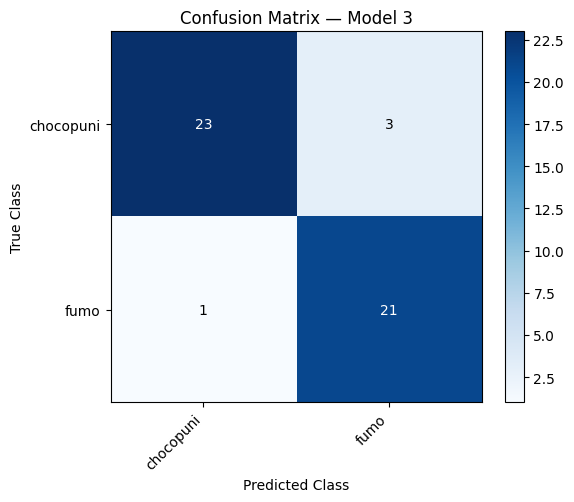

              precision    recall  f1-score   support

   chocopuni       0.96      0.88      0.92        26
        fumo       0.88      0.95      0.91        22

    accuracy                           0.92        48
   macro avg       0.92      0.92      0.92        48
weighted avg       0.92      0.92      0.92        48



In [11]:
all_preds, all_labels = [], []

model.eval()
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(DEVICE))
    preds = outputs.argmax(1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("Confusion Matrix — Model 3")

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## 12. Comparison — All Three Models

The final cell compares all three models side by side.

Update `model1_acc` and `model2_acc` with your actual results before running.

### What differences to analyze:
- **Model 1 vs Model 2:** Impact of pretrained features vs training from scratch
- **Model 2 vs Model 3:** Impact of fine-tuning upper layers vs fully frozen backbone
- **Val acc vs Test acc gap:** How well each approach generalizes to truly wild images
- **Trainable parameters:** More params didn't necessarily mean better results on this dataset size

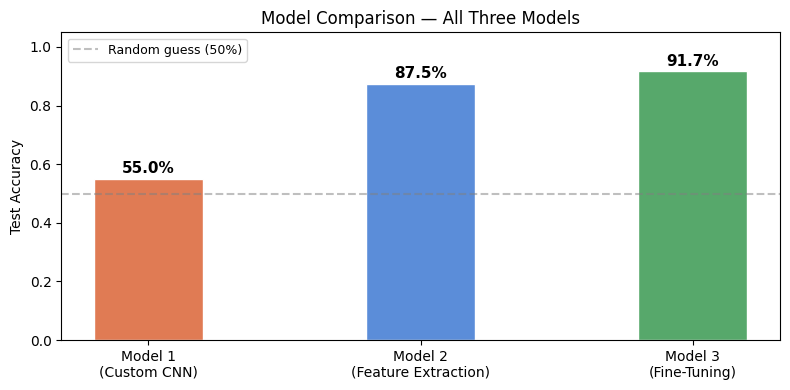

Model 1 → Model 2: +32.5 pp
Model 2 → Model 3: +4.2 pp
Model 1 → Model 3: +36.7 pp


In [12]:
model1_acc = 0.55   # ← update with your Model 1 test accuracy
model2_acc = 0.875  # ← update with your Model 2 test accuracy
model3_acc = test_acc

model_names = [
    "Model 1\n(Custom CNN)",
    "Model 2\n(Feature Extraction)",
    "Model 3\n(Fine-Tuning)",
]
results = [model1_acc, model2_acc, model3_acc]
colors  = ["#e07b54", "#5b8dd9", "#57a86b"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(model_names, results, color=colors, width=0.4, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Comparison — All Three Models")
ax.axhline(
    y=1/NUM_CLASSES, color="gray", linestyle="--", alpha=0.5,
    label=f"Random guess ({1/NUM_CLASSES:.0%})"
)
ax.legend(fontsize=9)
for bar, val in zip(bars, results):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
        f"{val:.1%}", ha="center", fontsize=11, fontweight="bold"
    )
plt.tight_layout()
plt.show()

print(f"Model 1 → Model 2: {(model2_acc - model1_acc)*100:+.1f} pp")
print(f"Model 2 → Model 3: {(model3_acc - model2_acc)*100:+.1f} pp")
print(f"Model 1 → Model 3: {(model3_acc - model1_acc)*100:+.1f} pp")

### Interpretation

Overall test accuracy of **91.7%** — the best result across all three models,
confirming that fine-tuning upper EfficientNet layers adds meaningful value
over pure feature extraction.

- **Both classes are well-balanced** (F1: 0.92 for Chocopuni, 0.91 for Fumo) —
  the class bias seen in Model 1 is completely gone
- **Chocopuni precision = 0.96** — nearly every Chocopuni prediction is correct
- **Fumo recall = 0.95** — the model finds almost all Fumo images in the test set
- Lower loss (0.392 vs 0.474 in Model 2) indicates the model is not only more
  accurate but also more confident in its correct predictions